In [ ]:
import os
import json
import zipfile
import requests
from PIL import Image
from io import BytesIO
from google.colab import files, drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


# Load and extract the Training images

In [ ]:
# Define the path to the ZIP file in Drive
zip_path = "/content/drive/MyDrive/VQA_Dataset/scene_img_abstract_v002_train2015.zip"
# Extract the dataset
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/drive/MyDrive/VQA_Dataset/scene_img_abstract_v002_train2015")

In [ ]:
# # Check if the file exists
# if os.path.exists(zip_path):
#     print("File exists!")
# else:
#     print("File not found! Check the path.")

File exists!


In [ ]:
# Define the path to the ZIP file in Drive
zip_path = "/content/drive/MyDrive/VQA_Dataset/scene_img_abstract_v002_test2015.zip"
# Extract the dataset
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/drive/MyDrive/VQA_Dataset/scene_img_abstract_v002_test2015")

In [ ]:
# Define the path to the ZIP file in Drive
zip_path = "/content/drive/MyDrive/VQA_Dataset/scene_img_abstract_v002_val2015.zip"
# Extract the dataset
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/drive/MyDrive/VQA_Dataset/scene_img_abstract_v002_val2015")

# STAGE 1 - Load the JSON files and combine questions, answers and images

In [ ]:
import pandas as pd
from tqdm import tqdm
import cv2
import matplotlib.pyplot as plt
import random
import string
import re
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

# STAGE 1.1 - LOAD AND PREPROCESS TRAINING SET

In [ ]:
# Define dataset paths
DATASET_DIR = "/content/drive/MyDrive/VQA_Dataset"
IMAGE_DIR = os.path.join(DATASET_DIR, "scene_img_abstract_v002_train2015")
QUESTIONS_PATH = os.path.join(DATASET_DIR, "MultipleChoice_abstract_v002_train2015_questions.json")
ANSWERS_PATH = os.path.join(DATASET_DIR, "abstract_v002_train2015_annotations.json")

# Ensure dataset directory exists
os.makedirs(DATASET_DIR, exist_ok=True)

# Function to load JSON files
def load_json(json_path):
    with open(json_path, "r") as file:
        return json.load(file)

In [ ]:
# Load the JSON files
questions = load_json(QUESTIONS_PATH)
answers = load_json(ANSWERS_PATH)

In [ ]:
# Convert JSON data into Pandas DataFrames
questions_df = pd.DataFrame(questions['questions'])
answers_df = pd.DataFrame(answers['annotations'])

In [ ]:
questions_df.head()

,image_id,question,multiple_choices,question_id
0,11779,Who looks happier?,"[alive, 1, woman, purple, 2, yes, white, boy, ...",117792
1,11779,Where is the woman sitting?,"[3, no, blue, red, 1, slide, monkey bars, jump...",117790
2,11779,Where is the man sitting?,"[away, yes, blue, 1, 2, mouse, couch, no, yell...",117791
3,5536,Is this man hungry?,"[water, yellow, 4, running, blue, pouring, out...",55360
4,5536,What kind of drink is that?,"[wine, girl would fall, soda, white, yes, coke...",55361


In [ ]:
answers_df.head()

,question_type,multiple_choice_answer,answers,image_id,answer_type,question_id
0,who,man,"[{'answer': 'old person', 'answer_confidence':...",11779,other,117792
1,where is the,blanket,"[{'answer': 'on blanket', 'answer_confidence':...",11779,other,117790
2,where is the,bench,"[{'answer': 'on bench', 'answer_confidence': '...",11779,other,117791
3,is this,yes,"[{'answer': 'yes', 'answer_confidence': 'yes',...",5536,yes/no,55360
4,what kind of,soda,"[{'answer': 'water', 'answer_confidence': 'no'...",5536,other,55361


In [ ]:
answers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   question_type           60000 non-null  object
 1   multiple_choice_answer  60000 non-null  object
 2   answers                 60000 non-null  object
 3   image_id                60000 non-null  int64 
 4   answer_type             60000 non-null  object
 5   question_id             60000 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 2.7+ MB


In [ ]:
# Merge the question and answer DataFrames (each question is matched with corresponding answers)
abstract_train2015 = pd.merge(questions_df, answers_df, on=["image_id", "question_id"])
abstract_train2015.head()

,image_id,question,multiple_choices,question_id,question_type,multiple_choice_answer,answers,answer_type
0,11779,Who looks happier?,"[alive, 1, woman, purple, 2, yes, white, boy, ...",117792,who,man,"[{'answer': 'old person', 'answer_confidence':...",other
1,11779,Where is the woman sitting?,"[3, no, blue, red, 1, slide, monkey bars, jump...",117790,where is the,blanket,"[{'answer': 'on blanket', 'answer_confidence':...",other
2,11779,Where is the man sitting?,"[away, yes, blue, 1, 2, mouse, couch, no, yell...",117791,where is the,bench,"[{'answer': 'on bench', 'answer_confidence': '...",other
3,5536,Is this man hungry?,"[water, yellow, 4, running, blue, pouring, out...",55360,is this,yes,"[{'answer': 'yes', 'answer_confidence': 'yes',...",yes/no
4,5536,What kind of drink is that?,"[wine, girl would fall, soda, white, yes, coke...",55361,what kind of,soda,"[{'answer': 'water', 'answer_confidence': 'no'...",other


In [ ]:
# Select relevant columns from merged dataframe
cols = ['image_id','question_id','question','question_type','multiple_choice_answer','answers','answer_type']
abstract_train2015 = abstract_train2015[cols]
abstract_train2015.head()

,image_id,question_id,question,question_type,multiple_choice_answer,answers,answer_type
0,11779,117792,Who looks happier?,who,man,"[{'answer': 'old person', 'answer_confidence':...",other
1,11779,117790,Where is the woman sitting?,where is the,blanket,"[{'answer': 'on blanket', 'answer_confidence':...",other
2,11779,117791,Where is the man sitting?,where is the,bench,"[{'answer': 'on bench', 'answer_confidence': '...",other
3,5536,55360,Is this man hungry?,is this,yes,"[{'answer': 'yes', 'answer_confidence': 'yes',...",yes/no
4,5536,55361,What kind of drink is that?,what kind of,soda,"[{'answer': 'water', 'answer_confidence': 'no'...",other


In [ ]:
abstract_train2015['answers'].iloc[0]

[{'answer': 'old person', 'answer_confidence': 'maybe', 'answer_id': 1},
 {'answer': 'man', 'answer_confidence': 'maybe', 'answer_id': 2},
 {'answer': 'man', 'answer_confidence': 'yes', 'answer_id': 3},
 {'answer': 'man', 'answer_confidence': 'yes', 'answer_id': 4},
 {'answer': 'old man', 'answer_confidence': 'yes', 'answer_id': 5},
 {'answer': 'man', 'answer_confidence': 'yes', 'answer_id': 6},
 {'answer': 'man', 'answer_confidence': 'yes', 'answer_id': 7},
 {'answer': 'man', 'answer_confidence': 'yes', 'answer_id': 8},
 {'answer': 'man', 'answer_confidence': 'yes', 'answer_id': 9},
 {'answer': 'grandpa', 'answer_confidence': 'yes', 'answer_id': 10}]

In [ ]:
# Create a list of answers from the answers column
abstract_train2015['answers'] = abstract_train2015['answers'].apply(lambda x: [dic['answer'] for dic in x])

In [ ]:
abstract_train2015['answers'].iloc[0]

['old person',
 'man',
 'man',
 'man',
 'old man',
 'man',
 'man',
 'man',
 'man',
 'grandpa']

In [ ]:
abstract_train2015['image_id'].iloc[0]

np.int64(11779)

In [ ]:
# convert image_id to image_path
def image_id_to_path(image_id):
    imdir = "/content/drive/MyDrive/VQA_Dataset/scene_img_abstract_v002_train2015/abstract_v002_train2015_%012d.png"
    return imdir % image_id

# Apply the function correctly using lambda (passing the column value dynamically)
abstract_train2015['image_id'] = abstract_train2015['image_id'].apply(image_id_to_path)

In [ ]:
abstract_train2015['image_id'].iloc[0]

'/content/drive/MyDrive/VQA_Dataset/scene_img_abstract_v002_train2015/abstract_v002_train2015_000000011779.png'

In [ ]:
# Save updated DataFrame to CSV
csv_path = "/content/drive/MyDrive/VQA_Dataset/abstract_train2015.csv"
abstract_train2015.to_csv(csv_path, index=False)

print(f"Updated CSV saved at: {csv_path}")

Updated CSV saved at: /content/drive/MyDrive/VQA_Dataset/abstract_train2015.csv


In [ ]:
print(questions_df.shape)
print(answers_df.shape)
print(abstract_train2015.shape)

(60000, 4)
(60000, 6)
(60000, 7)


## Load Merged Dataframe for preprocessing

Load merged data frame with questions, answers and image path

In [ ]:
abstract_train2015 = pd.read_csv("/content/drive/MyDrive/VQA_Dataset/abstract_train2015.csv")
print('Number of Question & Answer in Abstract Train Dataset:',len(abstract_train2015))
abstract_train2015.image_id[0]

Number of Question & Answer in Abstract Train Dataset: 60000


'/content/drive/MyDrive/VQA_Dataset/scene_img_abstract_v002_train2015/abstract_v002_train2015_000000011779.png'

In [ ]:
dataset_path = "/content/drive/MyDrive/VQA_Dataset/scene_img_abstract_v002_train2015/"
image_path = list(abstract_train2015['image_id'])
question = list(abstract_train2015['question'])
answer = list(abstract_train2015['multiple_choice_answer'])

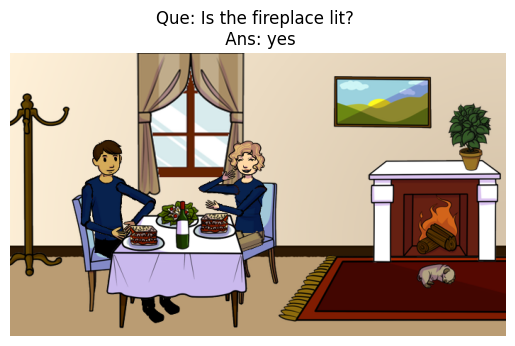

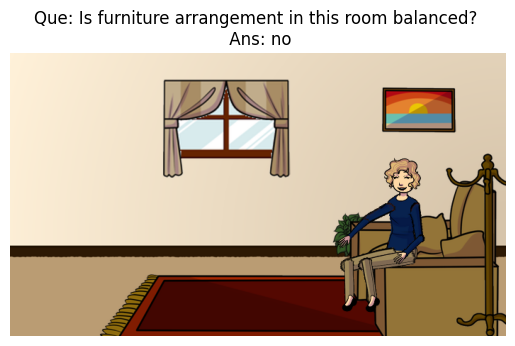

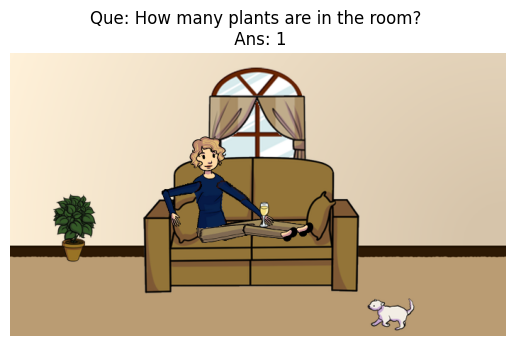

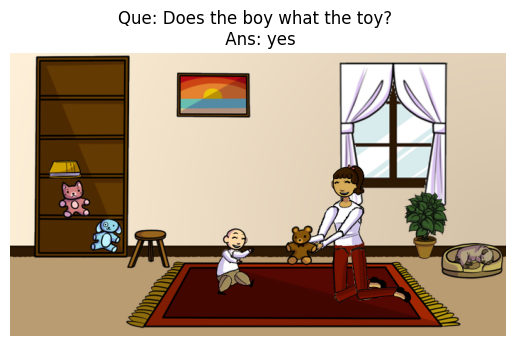

In [ ]:
# Plot sample images, questions and answers
temp = random.sample(range(len(image_path)), 4)

for i in temp:
    img_path = image_path[i]

    # Read the image using OpenCV
    image = cv2.imread(img_path)

    # Convert BGR to RGB for Matplotlib
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Display the image with question and answer
    plt.figure()
    plt.title(f'Que: {question[i]} \n Ans: {answer[i]}')
    plt.imshow(image)
    plt.axis("off")  # Hide axes
    plt.show()


In [ ]:
# Function to find punctuation in text
def find_punctuation(text_list):
    return list(set(char for text in text_list for char in text if char in string.punctuation))

que_punct_list = find_punctuation(question)
ans_punct_list = find_punctuation(answer)
print(f'{len(que_punct_list)} punctuations found in the Question Dataset:\n{que_punct_list}')
print('-'*100)
print(f'{len(ans_punct_list)} punctuations found in the Answer Dataset:\n{ans_punct_list}')

11 punctuations found in the Question Dataset:
['?', "'", ')', '"', '/', ':', '.', '(', '-', ';', ',']
----------------------------------------------------------------------------------------------------
8 punctuations found in the Answer Dataset:
['?', "'", '"', ':', '%', '.', '-', ',']


Observations:

- Above is a list of 11 punctuations found in the question dataset and 8 punctuations found in the answer dataset.
- Hence, we need to perform data cleaning operation on question and answer dataset before EDA.
- In this problem, we will consider answers as multiple classes and consider this problem as a multi-class classification problem.

In [ ]:
def expand_contractions(phrase):
    # Expand the contractions
    phrase = re.sub(r"won\'t", "will not", phrase)
    phrase = re.sub(r"can\'t", "can not", phrase)
    phrase = re.sub(r"won\’t", "will not", phrase)
    phrase = re.sub(r"can\’t", "can not", phrase)

    phrase = re.sub(r"he\'s", "he is", phrase)
    phrase = re.sub(r"she\'s", "she is", phrase)
    phrase = re.sub(r"it\'s", "it is", phrase)

    phrase = re.sub(r"he\’s", "he is", phrase)
    phrase = re.sub(r"she\’s", "she is", phrase)
    phrase = re.sub(r"it\’s", "it is", phrase)

    phrase = re.sub(r"n\'t", " not", phrase)
    phrase = re.sub(r"\'re", " are", phrase)
    phrase = re.sub(r"\'d", " would", phrase)
    phrase = re.sub(r"\'ll", " will", phrase)
    phrase = re.sub(r"\'t", " not", phrase)
    phrase = re.sub(r"\'ve", " have", phrase)
    phrase = re.sub(r"\'m", " am", phrase)

    return phrase

In [ ]:
def text_preprocess_qns(text):
    text = text.lower()
    text = expand_contractions(text) # replace contractions into natural form
    text = re.sub('[-,:]', ' ', text) # replace the character "-" "," with space
    text = re.sub("(?!<=\d)(\.)(?!\d)", '', text) # remove the character ".", except from floating numbers
    text = re.sub('[^A-Za-z0-9. ]+', '', text) # remove all punctuation, except A-Za-z0-9
    text = re.sub(' +', ' ', text) # remove extra space
    return text

In [ ]:
def text_preprocess_ans(text):
    text = text.lower()
    text = expand_contractions(text) # replace contractions into natural form
    text = re.sub('[-,:]', ' ', text) # replace the character "-" "," with space
    text = re.sub("(?!<=\d)(\.)(?!\d)", '', text) # remove the character ".", except from floating numbers
    text = re.sub('[^A-Za-z0-9.! ]+', '', text) # remove all punctuation, except A-Za-z0-9
    text = re.sub(' +', ' ', text) # remove extra space
    return text

In [ ]:
# Question and Answer text preprocessing
abstract_train2015["question_preprocessed"] = abstract_train2015["question"].map(lambda x: text_preprocess_qns(x))
abstract_train2015["answer_preprocessed"] = abstract_train2015["multiple_choice_answer"].map(lambda x: text_preprocess_ans(x))

In [ ]:
# Sample Questions and Answers Before and after text preprocessing
temp = random.sample(range(0, len(abstract_train2015)), 4)
for i in temp:
    print(f'Que: {abstract_train2015["question"][i]}\nAns: {abstract_train2015["multiple_choice_answer"][i]}')
print('-'*50)
for i in temp:
    print(f'Que: {abstract_train2015["question_preprocessed"][i]}\nAns: {abstract_train2015["answer_preprocessed"][i]}')

Que: How many windows are there?
Ans: 2
Que: Where is the blanket?
Ans: grass
Que: If this is in Canada is this more likely to be happening in January or July?
Ans: july
Que: Are these two girls sharing in a friendly manner?
Ans: yes
--------------------------------------------------
Que: how many windows are there
Ans: 2
Que: where is the blanket
Ans: grass
Que: if this is in canada is this more likely to be happening in january or july
Ans: july
Que: are these two girls sharing in a friendly manner
Ans: yes


- All the punctuations in question and answer are now removed

In [ ]:
abstract_train2015 = abstract_train2015.drop(['question', 'multiple_choice_answer'], axis=1)

cols = ['image_id','question_id','question_preprocessed','question_type','answer_preprocessed','answers','answer_type']
abstract_train2015 = abstract_train2015[cols]

print('Number of Question & Answer in Train Dataset:',len(abstract_train2015))
abstract_train2015.head(2)

Number of Question & Answer in Train Dataset: 60000


,image_id,question_id,question_preprocessed,question_type,answer_preprocessed,answers,answer_type
0,/content/drive/MyDrive/VQA_Dataset/scene_img_a...,117792,who looks happier,who,man,"['old person', 'man', 'man', 'man', 'old man',...",other
1,/content/drive/MyDrive/VQA_Dataset/scene_img_a...,117790,where is the woman sitting,where is the,blanket,"['on blanket', 'blanket', 'on blanket', 'blank...",other


In [ ]:
import pandas as pd
# save dataframe to .csv
abstract_train2015.to_csv("/content/drive/MyDrive/VQA_Dataset/abstract_train2015_preprocessed.csv",index=False)

 # STAGE 2.2 - LOAD AND PREPROCESS VALIDATION SET

In [ ]:
# Define dataset paths
DATASET_DIR = "/content/drive/MyDrive/VQA_Dataset"
IMAGE_DIR = os.path.join(DATASET_DIR, "scene_img_abstract_v002_val2015")
QUESTIONS_PATH = os.path.join(DATASET_DIR, "MultipleChoice_abstract_v002_val2015_questions.json")
ANSWERS_PATH = os.path.join(DATASET_DIR, "abstract_v002_val2015_annotations.json")

In [ ]:
# Ensure dataset directory exists
os.makedirs(DATASET_DIR, exist_ok=True)

# Function to load JSON files
def load_json(json_path):
    with open(json_path, "r") as file:
        return json.load(file)

In [ ]:
# Load datasets
questions_df = pd.DataFrame(load_json(QUESTIONS_PATH)['questions'])
answers_df = pd.DataFrame(load_json(ANSWERS_PATH)['annotations'])

In [ ]:
questions_df.head()

,image_id,question,multiple_choices,question_id
0,27578,Is the dog asleep?,"[white, picnicking, yes, hot, dog and girl, bl...",275780
1,27578,What is the man looking at?,"[monkey bars, drinking, dog, red, blue, son, b...",275781
2,27578,Is the man sitting on the armrest?,"[2, brown, wider, sitting, yes, marriage, red,...",275782
3,21768,Did she bake the pie?,"[golden girls, sky, 1, blue, 2, 4, no, feeding...",217680
4,21768,What is resting on the table besides the pie?,"[brown, air, cumulus, no, it is playing, wine ...",217681


In [ ]:
answers_df.head()

,question_type,multiple_choice_answer,answers,image_id,answer_type,question_id
0,is the dog,yes,"[{'answer': 'yes', 'answer_confidence': 'yes',...",27578,yes/no,275780
1,what is the man,tv,"[{'answer': 'tv', 'answer_confidence': 'yes', ...",27578,other,275781
2,is the man,yes,"[{'answer': 'yes', 'answer_confidence': 'yes',...",27578,yes/no,275782
3,none of the above,yes,"[{'answer': 'yes', 'answer_confidence': 'yes',...",21768,yes/no,217680
4,what is,wine glass,"[{'answer': 'wine glass', 'answer_confidence':...",21768,other,217681


In [ ]:
# Merge datasets & select relevant columns
abstract_val2015 = pd.merge(questions_df, answers_df, on=["image_id", "question_id"])[
    ['image_id', 'question_id', 'question', 'question_type',
     'multiple_choice_answer', 'answers', 'answer_type']
]

In [ ]:
# Convert answers to list
abstract_val2015['answers'] = abstract_val2015['answers'].apply(lambda x: [dic['answer'] for dic in x])

In [ ]:
# Convert image_id to image_path
abstract_val2015['image_id'] = abstract_val2015['image_id'].apply(
    lambda img_id: f"{IMAGE_DIR}/abstract_v002_val2015_{img_id:012d}.png"
)

In [ ]:
abstract_val2015['image_id'].iloc[0]

'/content/drive/MyDrive/VQA_Dataset/scene_img_abstract_v002_val2015/abstract_v002_val2015_000000027578.png'

In [ ]:
image_path = list(abstract_val2015['image_id'])
question = list(abstract_val2015['question'])
answer = list(abstract_val2015['multiple_choice_answer'])

In [ ]:
# Function to find punctuation in text
def find_punctuation(text_list):
    return list(set(char for text in text_list for char in text if char in string.punctuation))

In [ ]:
que_punct_list = find_punctuation(question)
ans_punct_list = find_punctuation(answer)
print(f'{len(que_punct_list)} punctuations found in the Question Dataset:\n{que_punct_list}')
print('-'*100)
print(f'{len(ans_punct_list)} punctuations found in the Answer Dataset:\n{ans_punct_list}')

13 punctuations found in the Question Dataset:
['?', "'", ')', '"', '`', '/', ':', '%', '.', '(', '-', ';', ',']
----------------------------------------------------------------------------------------------------
5 punctuations found in the Answer Dataset:
["'", ')', '(', '-', ',']


In [ ]:
# Question and Answer text preprocessing
abstract_val2015["question_preprocessed"] = abstract_val2015["question"].map(lambda x: text_preprocess_qns(x))
abstract_val2015["answer_preprocessed"] = abstract_val2015["multiple_choice_answer"].map(lambda x: text_preprocess_ans(x))

In [ ]:
abstract_val2015 = abstract_val2015.drop(['question', 'multiple_choice_answer'], axis=1)

cols = ['image_id','question_id','question_preprocessed','question_type','answer_preprocessed','answers','answer_type']
abstract_val2015 = abstract_val2015[cols]

print('Number of Question & Answer in Train Dataset:',len(abstract_val2015))
abstract_val2015.head(2)

Number of Question & Answer in Train Dataset: 30000


,image_id,question_id,question_preprocessed,question_type,answer_preprocessed,answers,answer_type
0,/content/drive/MyDrive/VQA_Dataset/scene_img_a...,275780,is the dog asleep,is the dog,yes,"[yes, yes, yes, yes, yes, yes, yes, yes, yes, ...",yes/no
1,/content/drive/MyDrive/VQA_Dataset/scene_img_a...,275781,what is the man looking at,what is the man,tv,"[tv, tv, tv, tv, tv, tv, tv, tv, tv, cat]",other


In [ ]:
# save dataframe to .csv
abstract_val2015.to_csv("/content/drive/MyDrive/VQA_Dataset/abstract_val2015_preprocessed.csv",index=False)

# Preprocess Test Dataset

In [ ]:
# Define dataset paths
DATASET_DIR = "/content/drive/MyDrive/VQA_Dataset"
IMAGE_DIR = os.path.join(DATASET_DIR, "scene_img_abstract_v002_test2015")
QUESTIONS_PATH = os.path.join(DATASET_DIR, "MultipleChoice_abstract_v002_test2015_questions.json")

In [ ]:
# Load datasets
abstract_test2015 = pd.DataFrame(load_json(QUESTIONS_PATH)['questions'])

In [ ]:
abstract_test2015.head()

,image_id,question,multiple_choices,question_id
0,39456,What color are the chairs?,"[red, 4, 3, plates, brown, yellow, green, stan...",394560
1,39456,Is the man asleep?,"[3, blue, 4, no, anger, white, 2, red, yes, on...",394561
2,39456,What is on the table?,"[white, on sidewalk, salt and pepper, 3, yes, ...",394562
3,47922,How many bushes are in the background?,"[blue, 1, 3, 40, dog, 10, 2, sun rays, red, ye...",479220
4,47922,What are they playing?,"[yes, soccer, on man's head, frisbee, golf, mo...",479221


In [ ]:
# Convert image_id to image_path
abstract_test2015['image_id'] = abstract_test2015['image_id'].apply(
    lambda img_id: f"{IMAGE_DIR}/abstract_test2015_{img_id:012d}.png"
)

In [ ]:
abstract_test2015['image_id'].iloc[0]

'/content/drive/MyDrive/VQA_Dataset/scene_img_abstract_v002_test2015/abstract_test2015_000000039456.png'

In [ ]:
image_path = list(abstract_test2015['image_id'])
question = list(abstract_test2015['question'])

In [ ]:
que_punct_list = find_punctuation(question)
print(f'{len(que_punct_list)} punctuations found in the Question Dataset:\n{que_punct_list}')

12 punctuations found in the Question Dataset:
['?', "'", ')', '"', '`', '/', ':', '&', '.', '(', '-', ',']


In [ ]:
abstract_test2015["question_preprocessed"] = abstract_test2015["question"].map(lambda x: text_preprocess_qns(x))

In [ ]:
abstract_test2015 = abstract_test2015.drop(['question'], axis=1)

In [ ]:
cols = ['image_id','question_id','question_preprocessed']
abstract_test2015 = abstract_test2015[cols]

In [ ]:
print('Number of Question & Answer in Train Dataset:',len(abstract_val2015))
abstract_val2015.head(2)

Number of Question & Answer in Train Dataset: 30000


,image_id,question_id,question_preprocessed,question_type,answer_preprocessed,answers,answer_type
0,/content/drive/MyDrive/VQA_Dataset/scene_img_a...,275780,is the dog asleep,is the dog,yes,"[yes, yes, yes, yes, yes, yes, yes, yes, yes, ...",yes/no
1,/content/drive/MyDrive/VQA_Dataset/scene_img_a...,275781,what is the man looking at,what is the man,tv,"[tv, tv, tv, tv, tv, tv, tv, tv, tv, cat]",other


In [ ]:
# save dataframe to .csv
abstract_test2015.to_csv("/content/drive/MyDrive/VQA_Dataset/abstract_test2015_preprocessed.csv",index=False)